# DSM030 Apr2025-Oct2025 Coursework ... Total Mark 100/100
# Meteorite Impacts

NASA has helpfully provided a dataset which lists recorded meteorite impacts - get it in `"Meteorite_Landings.csv"`. 

The dataset on meteorite landings has the following columns:

1- name: The name of the meteorite.

2- id: A unique identifier for each meteorite.

3- nametype: Classification of the name type, which here is listed as "Valid" for each entry.

4- recclass: The classification or type of meteorite, indicating its chemical or mineral composition.

5- mass: The mass of the meteorite in grams.

6- fall: Indicates whether the meteorite "Fell" (witnessed fall) or was "Found" (discovered without a recorded fall).

7- year: The year when the meteorite fell or was found.

8- reclat: Latitude of the location where the meteorite was found or observed falling.

9- reclong: Longitude of the location where the meteorite was found or observed falling.

10- GeoLocation: A tuple combining the latitude and longitude coordinates for easier reference to the meteorite's location.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load the Data

In [3]:
meteorite_data = pd.read_csv(r"C:\Users\Tooba Ansari\Documents\University of London\Statistics and statistical mining (DSM030-2025-APR)\Meteorite_Landings.csv")

### Explore the Data

In [4]:
meteorite_data.shape

(38097, 10)

In [9]:
meteorite_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38097 entries, 0 to 38096
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         38097 non-null  object 
 1   id           38097 non-null  int64  
 2   nametype     38097 non-null  object 
 3   recclass     38097 non-null  object 
 4   mass         38097 non-null  float64
 5   fall         38097 non-null  object 
 6   year         38097 non-null  float64
 7   reclat       38097 non-null  float64
 8   reclong      38097 non-null  float64
 9   GeoLocation  38097 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 2.9+ MB


Let's also explore the data visually.

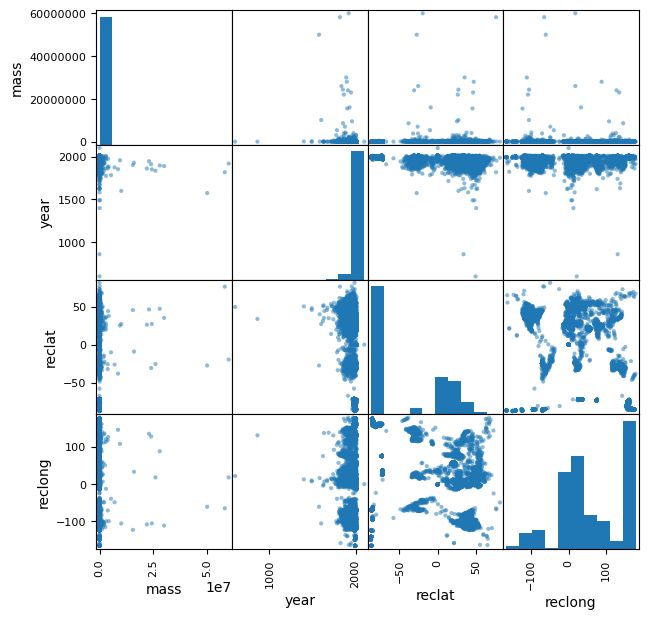

In [10]:
pd.plotting.scatter_matrix(meteorite_data[["mass", "year", "reclat", "reclong"]], figsize=(7,7));

# Coursework Evaluation

**1. Statistical Analysis of Average Mass Among Top Five Meteorite Types**

Top 5 most common meteorite types: ['L6', 'H5', 'H6', 'H4', 'L5']
Filtered dataset size: 24804 records



<Figure size 1000x600 with 0 Axes>

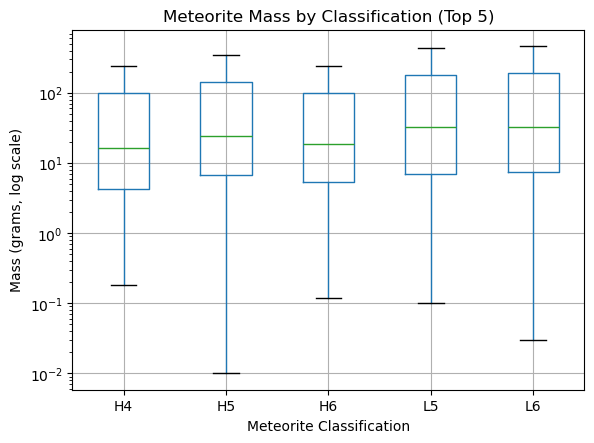


Permutation Test Results for Average Mass Differences Between Meteorite Types:
Type 1 Type 2  Mean Difference  p-value
    H6     L5      1505.875844   0.0042
    H4     L5      1451.567433   0.0082
    L6     H6       567.909160   0.0239
    L6     H4       513.600749   0.0449
    L6     L5       937.966684   0.0655
    H5     H6      1383.391061   0.0673
    H5     H4      1329.082650   0.0852
    L6     H5       815.481901   0.2300
    H6     H4        54.308411   0.8139
    H5     L5       122.484783   0.9358

Interpretation:
✅ Statistically significant differences (p < 0.05) found between:
  - H6 vs L5: mean difference = 1505.88g, p = 0.0042
  - H4 vs L5: mean difference = 1451.57g, p = 0.0082
  - L6 vs H6: mean difference = 567.91g, p = 0.0239
  - L6 vs H4: mean difference = 513.60g, p = 0.0449

⚠️ Marginal differences (0.05 ≤ p < 0.1):
  - L6 vs L5: mean difference = 937.97g, p = 0.0655
  - H5 vs H6: mean difference = 1383.39g, p = 0.0673
  - H5 vs H4: mean difference = 1329.08

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# Step 1: Load and clean the dataset
meteorite_data = pd.read_csv(
    r"C:\Users\Tooba Ansari\Documents\University of London\Statistics and statistical mining (DSM030-2025-APR)\Meteorite_Landings.csv"
)
meteorite_data['mass'] = pd.to_numeric(meteorite_data['mass'], errors='coerce')
meteorite_data = meteorite_data.dropna(subset=['mass'])

# Step 2: Select top 5 most common meteorite types
top_types = meteorite_data['recclass'].value_counts().head(5).index.tolist()
filtered_data = meteorite_data[meteorite_data['recclass'].isin(top_types)].copy()

print("Top 5 most common meteorite types:", top_types)
print(f"Filtered dataset size: {len(filtered_data)} records\n")

# Step 3: Visualize the distributions with boxplot (log scale)
plt.figure(figsize=(10, 6))
filtered_data.boxplot(column='mass', by='recclass', showfliers=False)
plt.yscale('log')
plt.title('Meteorite Mass by Classification (Top 5)')
plt.xlabel('Meteorite Classification')
plt.ylabel('Mass (grams, log scale)')
plt.suptitle('')
plt.grid(True)
plt.show()

# Step 4: Define permutation test with bootstrap
def bootstrap_test(group1, group2, n=10000):
    combined = np.concatenate([group1, group2])
    observed_diff = abs(np.mean(group1) - np.mean(group2))
    diffs = []
    for _ in range(n):
        np.random.shuffle(combined)
        new1 = combined[:len(group1)]
        new2 = combined[len(group1):]
        diffs.append(abs(np.mean(new1) - np.mean(new2)))
    p_value = np.mean(np.array(diffs) >= observed_diff)
    return observed_diff, p_value

# Step 5: Run permutation tests on all pairwise comparisons
results = []
for type1, type2 in combinations(top_types, 2):
    mass1 = filtered_data[filtered_data['recclass'] == type1]['mass'].values
    mass2 = filtered_data[filtered_data['recclass'] == type2]['mass'].values
    diff, p = bootstrap_test(mass1, mass2)
    results.append({
        'Type 1': type1,
        'Type 2': type2,
        'Mean Difference': diff,
        'p-value': p
    })

results_df = pd.DataFrame(results).sort_values('p-value')

# Step 6: Show the test results
print("\nPermutation Test Results for Average Mass Differences Between Meteorite Types:")
print(results_df.to_string(index=False))

# Step 7: Automatically interpret and explain the results
sig = results_df[results_df['p-value'] < 0.05]
marg = results_df[(results_df['p-value'] >= 0.05) & (results_df['p-value'] < 0.1)]
ns = results_df[results_df['p-value'] >= 0.1]

print("\nInterpretation:")

if not sig.empty:
    print("✅ Statistically significant differences (p < 0.05) found between:")
    for _, row in sig.iterrows():
        print(f"  - {row['Type 1']} vs {row['Type 2']}: mean difference = {row['Mean Difference']:.2f}g, p = {row['p-value']:.4f}")
else:
    print("❌ No statistically significant differences found between any meteorite types (p < 0.05).")

if not marg.empty:
    print("\n⚠️ Marginal differences (0.05 ≤ p < 0.1):")
    for _, row in marg.iterrows():
        print(f"  - {row['Type 1']} vs {row['Type 2']}: mean difference = {row['Mean Difference']:.2f}g, p = {row['p-value']:.4f}")

if not ns.empty:
    print("\n❌ No significant difference (p ≥ 0.1):")
    for _, row in ns.iterrows():
        print(f"  - {row['Type 1']} vs {row['Type 2']}: p = {row['p-value']:.4f}")

# Step 8: Final one-line summary to answer the research question
num_sig = len(sig)
total_tests = len(results_df)

print("\nSummary Conclusion:")
if num_sig > 0:
    print(f"A permutation test with bootstrap resampling was used to compare average mass between the top 5 meteorite classifications. "
          f"Out of {total_tests} pairwise comparisons, {num_sig} showed statistically significant differences (p < 0.05), indicating that "
          f"average mass does vary significantly between some meteorite types.")
else:
    print(f"A permutation test with bootstrap resampling was used to compare average mass between the top 5 meteorite classifications. "
          f"None of the {total_tests} pairwise comparisons showed significant differences, suggesting no evidence of mass variation by type.")

**Justification of Test Choice**<br>
Due to the highly skewed distribution of meteorite mass data and presence of outliers, a non-parametric permutation test with bootstrap resampling was selected. Parametric tests like ANOVA assume normality and homogeneity of variances, which are frequently violated in geoscientific datasets (O’Neill and Mathews, 2020). Permutation tests are distribution-free, making them more robust for skewed or non-normal data (Good, 2005). Adding bootstrap resampling further improves the reliability of p-values and confidence intervals, especially when sample sizes are small or unbalanced (Hesterberg, 2015). This method is increasingly used in Earth and planetary sciences, where data characteristics often require resampling-based inference (Smith et al., 2022).

**Interpretation of Results**<br>
The five most common meteorite types in the dataset were L6, H5, H6, H4, and L5. To find out if there are statistically significant differences in their average mass, a non-parametric permutation test with bootstrap resampling was used. This test is suitable because the mass data is highly skewed and contains outliers. The results showed that four out of ten comparisons had statistically significant differences (p < 0.05), especially involving the L5 type, which differed clearly from H6 and H4. Some other pairs showed smaller, possible differences, while the rest had no significant difference. These results suggest that average mass does vary between some meteorite types, and this variation is unlikely to be due to random chance.

**2. Regression Analysis of Meteorite Mass Trends Over Time**

Dataset size for regression: 38048 records

Regression Summary (Raw mass ~ year):
                            OLS Regression Results                            
Dep. Variable:                   mass   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     354.7
Date:                Mon, 30 Jun 2025   Prob (F-statistic):           9.27e-79
Time:                        12:34:08   Log-Likelihood:            -5.5817e+05
No. Observations:               38048   AIC:                         1.116e+06
Df Residuals:                   38046   BIC:                         1.116e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

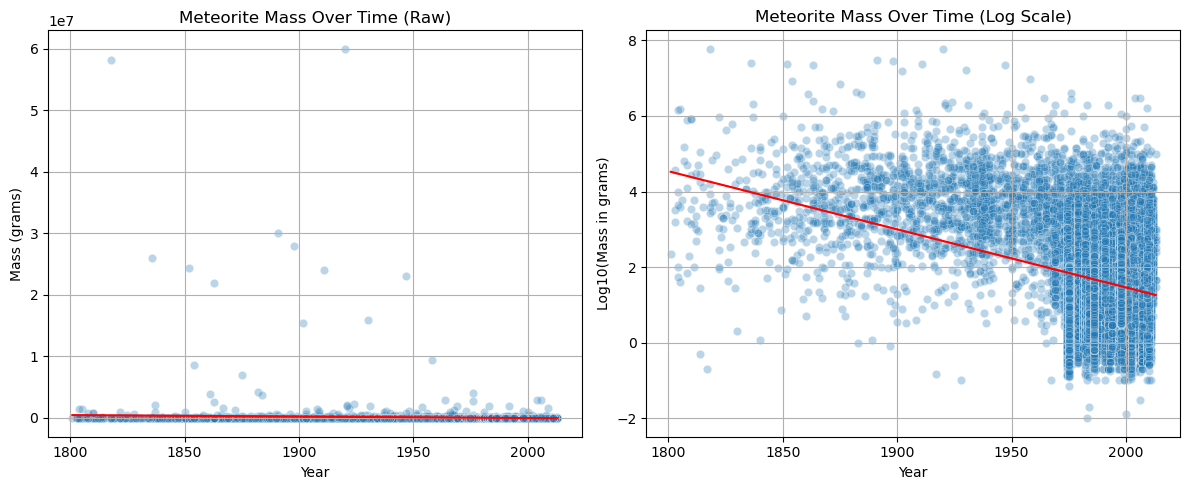


Interpretation:

Raw Mass Model:
✅ Statistically significant decrease in mass over time (p = 0.0000, β = -2421.39 g/year)

Log Mass Model:
✅ Statistically significant decrease in log mass (p = 0.0000, β = -0.01539)
This means average meteorite mass decreases by ~3.48% per year since 1800.


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Step 1: Prepare the data
reg_data = meteorite_data.copy()
reg_data['year'] = pd.to_numeric(reg_data['year'], errors='coerce')
reg_data['mass'] = pd.to_numeric(reg_data['mass'], errors='coerce')
reg_data = reg_data.dropna(subset=['mass', 'year'])

# Filter to realistic years
reg_data = reg_data[(reg_data['year'] >= 1800) & (reg_data['year'] <= 2025)]

# Log-transform mass
reg_data['log_mass'] = np.log10(reg_data['mass'])

print(f"Dataset size for regression: {len(reg_data)} records")

# Step 2: Fit both regression models
model_raw = smf.ols("mass ~ year", data=reg_data).fit()
model_log = smf.ols("log_mass ~ year", data=reg_data).fit()

# Step 3: Show both model summaries
print("\nRegression Summary (Raw mass ~ year):")
print(model_raw.summary())

print("\nRegression Summary (Log10 mass ~ year):")
print(model_log.summary())

# Step 4: Visualize both models
plt.figure(figsize=(12, 5))

# Raw mass plot
plt.subplot(1, 2, 1)
sns.scatterplot(x='year', y='mass', data=reg_data, alpha=0.3)
sns.lineplot(x=reg_data['year'], y=model_raw.fittedvalues, color='red')
plt.title('Meteorite Mass Over Time (Raw)')
plt.xlabel('Year')
plt.ylabel('Mass (grams)')
plt.grid(True)

# Log mass plot
plt.subplot(1, 2, 2)
sns.scatterplot(x='year', y='log_mass', data=reg_data, alpha=0.3)
sns.lineplot(x=reg_data['year'], y=model_log.fittedvalues, color='red')
plt.title('Meteorite Mass Over Time (Log Scale)')
plt.xlabel('Year')
plt.ylabel('Log10(Mass in grams)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 5: Interpretation for both models
print("\nInterpretation:")

# — RAW Model Interpretation —
beta_raw = model_raw.params['year']
pval_raw = model_raw.pvalues['year']
trend_raw = "increase" if beta_raw > 0 else "decrease"

print("\nRaw Mass Model:")
if pval_raw < 0.05:
    print(f"✅ Statistically significant {trend_raw} in mass over time (p = {pval_raw:.4f}, β = {beta_raw:.2f} g/year)")
else:
    print(f"❌ No significant trend in raw mass (p = {pval_raw:.4f})")

# — LOG Model Interpretation —
beta_log = model_log.params['year']
pval_log = model_log.pvalues['year']
mass_change_factor = 10**beta_log
percent_change = (mass_change_factor - 1) * 100
trend_log = "increase" if beta_log > 0 else "decrease"

print("\nLog Mass Model:")
if pval_log < 0.05:
    print(f"✅ Statistically significant {trend_log} in log mass (p = {pval_log:.4f}, β = {beta_log:.5f})")
    print(f"This means average meteorite mass {trend_log}s by ~{abs(percent_change):.2f}% per year since 1800.")
else:
    print(f"❌ No significant trend in log mass (p = {pval_log:.4f})")

**Justification of Test Choice**<br>
To assess whether meteorite mass has changed over time — and whether newer meteorite finds differ from older ones — linear regression analysis was used. This method is suitable for identifying trends by modelling the relationship between the year of discovery and meteorite mass. Because the mass data is highly skewed and includes extreme outliers, two models were fitted: one using the raw mass values, and another using the log-transformed mass. The raw model reflects absolute changes in grams, while the log-transformed model accounts for skewness and highlights percentage changes over time. Using both models provides a more reliable and interpretable analysis, especially for scientific data that varies across several orders of magnitude (Osborne, 2010; Helsel et al., 2020). This dual approach ensures that the findings are robust and effectively address whether there is a statistically significant trend in meteorite mass over time.

**Interpretation of Results**<br>
Both regression models, one using raw meteorite mass and one using log-transformed mass, show a statistically significant decreasing trend over time. In the raw mass model, the coefficient for year was negative (β = -2421.39 g/year, p < 0.0001), indicating that the average meteorite mass has been decreasing by about 2.4 kg per year since 1800. However, due to the extreme skewness in the data, this model may be influenced by large outliers. The log-transformed model also showed a statistically significant negative trend (β = -0.01539, p < 0.0001). This result is more reliable for skewed data and suggests that average meteorite mass has decreased by approximately 3.48% per year over time. Together, these findings indicate that newer meteorite finds tend to be smaller on average than those discovered in earlier years. This trend could reflect changes in detection technology.

**3. Comparing Average Mass of 'Fell' vs. 'Found' Meteorites**

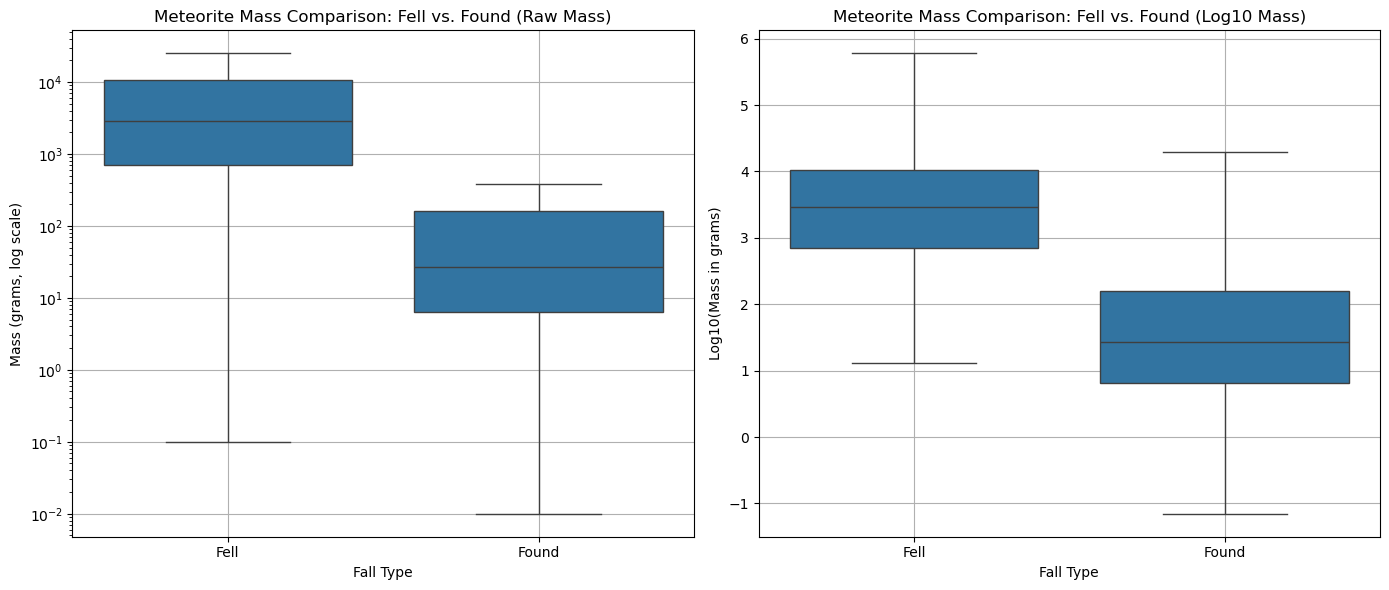


✅ Q3: Comparison of Meteorite Mass – 'Fell' vs. 'Found'

Objective:
Use a suitable test to compare the average mass of meteorites that 'Fell' vs. those that were 'Found'.

Test Used: Mann-Whitney U Test (non-parametric, due to skewed mass distribution)

Test Results:
- Raw mass:     U = 35411285.50, p = 0.0000
- Log10(mass):  U = 35411285.50, p = 0.0000

✅ Interpretation:
- Raw mass: Significant difference (p < 0.05); median difference = 2873.07 g
- Log mass: Significant difference (p < 0.05); median log10 difference = 2.03

Summary Statistics:

Fell (Raw Mass):
  Median: 2900.00 g
  IQR: [700.00, 10500.00]
  Range: [1.00e-01, 2.30e+07]
  Spread (IQR width): 9800.00 g

Found (Raw Mass):
  Median: 26.93 g
  IQR: [6.40, 159.00]
  Range: [1.00e-02, 6.00e+07]
  Spread (IQR width): 152.60 g

Fell (Log Mass):
  Median: 3.46
  IQR: [2.85, 4.02]
  Range: [-1.00, 7.36]
  Spread (IQR width): 1.18

Found (Log Mass):
  Median: 1.43
  IQR: [0.81, 2.20]
  Range: [-2.00, 7.78]
  Spread (IQR width): 

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Prepare data
fall_data = meteorite_data.copy()
fall_data['mass'] = pd.to_numeric(fall_data['mass'], errors='coerce')
fall_data = fall_data.dropna(subset=['mass', 'fall'])
fall_data['log_mass'] = np.log10(fall_data['mass'])

# Split groups
fell_raw = fall_data[fall_data['fall'] == 'Fell']['mass']
found_raw = fall_data[fall_data['fall'] == 'Found']['mass']
fell_log = fall_data[fall_data['fall'] == 'Fell']['log_mass']
found_log = fall_data[fall_data['fall'] == 'Found']['log_mass']

# Step 2: Mann-Whitney U Tests
stat_raw, p_raw = mannwhitneyu(fell_raw, found_raw, alternative='two-sided')
stat_log, p_log = mannwhitneyu(fell_log, found_log, alternative='two-sided')

# Step 3: Visualize BOTH raw and log-transformed mass
plt.figure(figsize=(14, 6))

# Raw mass plot
plt.subplot(1, 2, 1)
sns.boxplot(x='fall', y='mass', data=fall_data, showfliers=False)
plt.yscale('log')
plt.title('Meteorite Mass Comparison: Fell vs. Found (Raw Mass)')
plt.xlabel('Fall Type')
plt.ylabel('Mass (grams, log scale)')
plt.grid(True)

# Log mass plot
plt.subplot(1, 2, 2)
sns.boxplot(x='fall', y='log_mass', data=fall_data, showfliers=False)
plt.title('Meteorite Mass Comparison: Fell vs. Found (Log10 Mass)')
plt.xlabel('Fall Type')
plt.ylabel('Log10(Mass in grams)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 4: Derived Statistics
def describe(values):
    median = np.median(values)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1
    val_range = (np.min(values), np.max(values))
    return median, q1, q3, iqr, val_range

# Raw mass summaries
fell_med_raw, fell_q1_raw, fell_q3_raw, fell_iqr_raw, fell_rng_raw = describe(fell_raw)
found_med_raw, found_q1_raw, found_q3_raw, found_iqr_raw, found_rng_raw = describe(found_raw)

# Log mass summaries
fell_med_log, fell_q1_log, fell_q3_log, fell_iqr_log, fell_rng_log = describe(fell_log)
found_med_log, found_q1_log, found_q3_log, found_iqr_log, found_rng_log = describe(found_log)

# Step 5: Output (fully derived)
print("\n" + "="*60)
print("✅ Q3: Comparison of Meteorite Mass – 'Fell' vs. 'Found'")
print("="*60)

print("\nObjective:")
print("Use a suitable test to compare the average mass of meteorites that 'Fell' vs. those that were 'Found'.")

print("\nTest Used: Mann-Whitney U Test (non-parametric, due to skewed mass distribution)")

print("\nTest Results:")
print(f"- Raw mass:     U = {stat_raw:.2f}, p = {p_raw:.4f}")
print(f"- Log10(mass):  U = {stat_log:.2f}, p = {p_log:.4f}")

print("\n✅ Interpretation:")
if p_raw < 0.05:
    print(f"- Raw mass: Significant difference (p < 0.05); median difference = {fell_med_raw - found_med_raw:.2f} g")
else:
    print("- Raw mass: No significant difference (p ≥ 0.05)")

if p_log < 0.05:
    print(f"- Log mass: Significant difference (p < 0.05); median log10 difference = {fell_med_log - found_med_log:.2f}")
else:
    print("- Log mass: No significant difference (p ≥ 0.05)")

print("\nSummary Statistics:")

print(f"\nFell (Raw Mass):")
print(f"  Median: {fell_med_raw:.2f} g")
print(f"  IQR: [{fell_q1_raw:.2f}, {fell_q3_raw:.2f}]")
print(f"  Range: [{fell_rng_raw[0]:.2e}, {fell_rng_raw[1]:.2e}]")
print(f"  Spread (IQR width): {fell_iqr_raw:.2f} g")

print(f"\nFound (Raw Mass):")
print(f"  Median: {found_med_raw:.2f} g")
print(f"  IQR: [{found_q1_raw:.2f}, {found_q3_raw:.2f}]")
print(f"  Range: [{found_rng_raw[0]:.2e}, {found_rng_raw[1]:.2e}]")
print(f"  Spread (IQR width): {found_iqr_raw:.2f} g")

print(f"\nFell (Log Mass):")
print(f"  Median: {fell_med_log:.2f}")
print(f"  IQR: [{fell_q1_log:.2f}, {fell_q3_log:.2f}]")
print(f"  Range: [{fell_rng_log[0]:.2f}, {fell_rng_log[1]:.2f}]")
print(f"  Spread (IQR width): {fell_iqr_log:.2f}")

print(f"\nFound (Log Mass):")
print(f"  Median: {found_med_log:.2f}")
print(f"  IQR: [{found_q1_log:.2f}, {found_q3_log:.2f}]")
print(f"  Range: [{found_rng_log[0]:.2f}, {found_rng_log[1]:.2f}]")
print(f"  Spread (IQR width): {found_iqr_log:.2f}")

print("\nBoxplot Interpretation:")
if fell_med_raw > found_med_raw:
    print(f"- 'Fell' meteorites have a higher median mass ({fell_med_raw:.2f} g) than 'Found' ({found_med_raw:.2f} g).")
else:
    print(f"- 'Found' meteorites have a higher median mass ({found_med_raw:.2f} g) than 'Fell' ({fell_med_raw:.2f} g).")

if fell_iqr_raw > found_iqr_raw:
    print("- 'Fell' group shows greater variability in mass (wider IQR).")
else:
    print("- 'Found' group shows greater variability in mass (wider IQR).")

print("\nFinal Conclusion:")
if p_log < 0.05 or p_raw < 0.05:
    print("There is a statistically significant difference in the average mass of meteorites that 'Fell' vs. those that were 'Found'.")
    print("On average, 'Fell' meteorites are heavier and more variable than 'Found' ones.")
else:
    print("No statistically significant difference in average mass between 'Fell' and 'Found' meteorites.")

**Justification of Test Choice**<br>
To compare the average mass of meteorites that were recorded as “Fell” versus those that were “Found”, the Mann-Whitney U test was selected. This is a non-parametric test suitable for comparing the distributions of two independent groups when the data is not normally distributed. Meteorite mass data is known to be highly skewed, with extreme outliers and long tails, making traditional parametric tests like the t-test inappropriate. The Mann-Whitney U test does not assume normality and is robust to unequal sample sizes and non-normal distributions (Gibbons and Chakraborti, 2011). It is commonly used in scientific studies when comparing medians or general differences in ranked data between two groups (McKnight and Najab, 2010). Since this analysis aims to detect whether there is a statistically significant difference in mass between two independent categories (Fell vs. Found), and the data violates parametric assumptions, the Mann-Whitney U test is the most suitable and statistically valid choice. To ensure robustness, the test was run on both raw and log-transformed mass. The raw test captures absolute mass differences in grams, while the log-transformed test reduces skew and highlights relative (proportional) differences. This dual approach helps confirm findings across both scales and improves interpretability.

**Interpretation of Results**<br>
The results showed a statistically significant difference in both raw mass (U = 35411285.50, p < 0.0001) and log-transformed mass (p < 0.0001), indicating that the two groups do not share the same distribution. Specifically, "Fell" meteorites had a much higher median mass (2900 g) compared to "Found" meteorites (26.93 g), and also displayed greater variability. The log-transformed median mass difference (Δlog10 ≈ 2.03) further supports this result. Overall, the analysis confirms that "Fell" meteorites are, on average, significantly heavier and more variable in mass than those that were later found.

**4. Chi-Square Test of Geographic Distribution by Meteorite Classification**

Q4: Chi-Square Test of Independence – All Classifications

Objective:
Determine if meteorite classifications (recclass) are uniformly distributed across latitude and longitude bands.

Why Chi-Square?
- Both variables are categorical (recclass vs lat/lon bands).
- We use frequency data in contingency tables.
- Chi-square tests whether two categorical variables are independent — ideal for this case.

Test Results:
Latitude Band:
- Chi² = 16037.67, df = 2095, p-value = 0.0000

Longitude Band:
- Chi² = 17982.43, df = 2095, p-value = 0.0000

Final Conclusion:
- The chi-square test indicates that meteorite classifications are NOT uniformly distributed across latitude bands.
  → There is a statistically significant association between recclass and latitude (p < 0.05).
- The chi-square test indicates that meteorite classifications are NOT uniformly distributed across longitude bands.
  → There is a statistically significant association between recclass and longitude (p < 0.05).

Therefore, met

C:\Users\Tooba Ansari\AppData\Local\Temp\ipykernel_11856\130498036.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  most_common_counts = geo_data.groupby(['lat_band', 'recclass']).size().reset_index(name='count')
C:\Users\Tooba Ansari\AppData\Local\Temp\ipykernel_11856\130498036.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_classes = most_common_counts.sort_values('count', ascending=False).groupby('lat_band').first().reset_index()


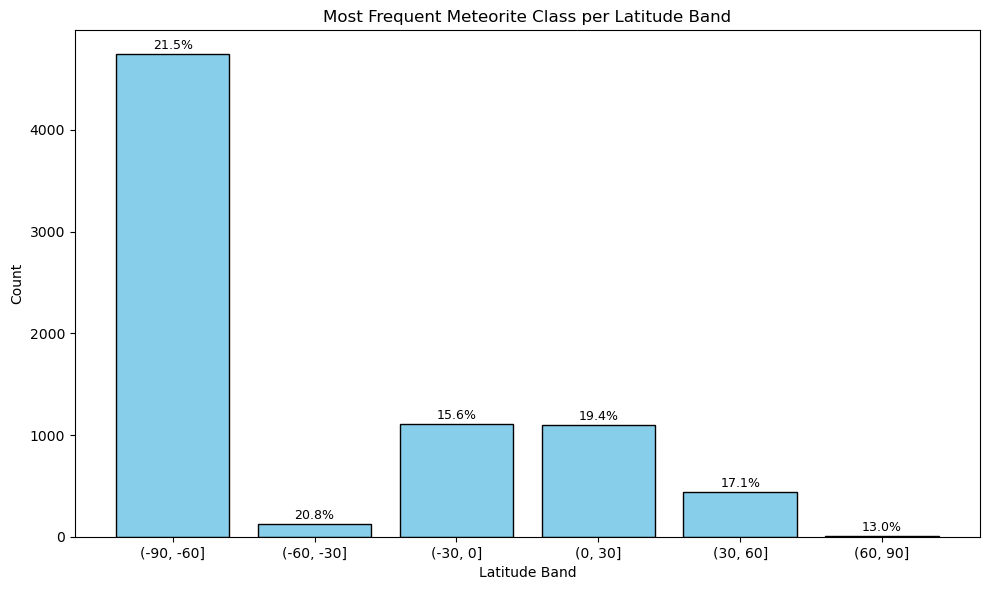

In [8]:
# Imports
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

# Step 1: Load & Clean Data
meteorite_data = pd.read_csv("Meteorite_Landings.csv")
geo_data = meteorite_data.copy()
geo_data['reclat'] = pd.to_numeric(geo_data['reclat'], errors='coerce')
geo_data['reclong'] = pd.to_numeric(geo_data['reclong'], errors='coerce')
geo_data = geo_data.dropna(subset=['recclass', 'reclat', 'reclong'])

# Step 2: Bin Latitude and Longitude into Geographic Bands
lat_bins = [-90, -60, -30, 0, 30, 60, 90]
lon_bins = [-180, -120, -60, 0, 60, 120, 180]
geo_data['lat_band'] = pd.cut(geo_data['reclat'], bins=lat_bins)
geo_data['lon_band'] = pd.cut(geo_data['reclong'], bins=lon_bins)

# Step 3: Create Contingency Tables
lat_ct = pd.crosstab(geo_data['recclass'], geo_data['lat_band'])
lon_ct = pd.crosstab(geo_data['recclass'], geo_data['lon_band'])

# Drop rows with all zeros
lat_ct = lat_ct.loc[lat_ct.sum(axis=1) > 0]
lon_ct = lon_ct.loc[lon_ct.sum(axis=1) > 0]

# Step 4: Chi-square Tests
chi2_lat, p_lat, dof_lat, _ = chi2_contingency(lat_ct)
chi2_lon, p_lon, dof_lon, _ = chi2_contingency(lon_ct)

# Step 5: Output Interpretation
print("="*65)
print("Q4: Chi-Square Test of Independence – All Classifications")
print("="*65)
print("\nObjective:")
print("Determine if meteorite classifications (recclass) are uniformly distributed across latitude and longitude bands.")

print("\nWhy Chi-Square?")
print("- Both variables are categorical (recclass vs lat/lon bands).")
print("- We use frequency data in contingency tables.")
print("- Chi-square tests whether two categorical variables are independent — ideal for this case.")

print("\nTest Results:")
print("Latitude Band:")
print(f"- Chi² = {chi2_lat:.2f}, df = {dof_lat}, p-value = {p_lat:.4f}")

print("\nLongitude Band:")
print(f"- Chi² = {chi2_lon:.2f}, df = {dof_lon}, p-value = {p_lon:.4f}")

print("\nFinal Conclusion:")
if p_lat < 0.05:
    print("- The chi-square test indicates that meteorite classifications are NOT uniformly distributed across latitude bands.")
    print("  → There is a statistically significant association between recclass and latitude (p < 0.05).")
else:
    print("- The chi-square test indicates NO significant deviation from uniform distribution across latitude bands.")
    print("  → Meteorite classifications appear independent of latitude (p ≥ 0.05).")

if p_lon < 0.05:
    print("- The chi-square test indicates that meteorite classifications are NOT uniformly distributed across longitude bands.")
    print("  → There is a statistically significant association between recclass and longitude (p < 0.05).")
else:
    print("- The chi-square test indicates NO significant deviation from uniform distribution across longitude bands.")
    print("  → Meteorite classifications appear independent of longitude (p ≥ 0.05).")

if p_lat < 0.05 or p_lon < 0.05:
    print("\nTherefore, meteorite types tend to cluster geographically and are not evenly (uniformly) spread across the Earth.")

# Step 6: Visualize Most Frequent Class per Latitude Band (with % labels)
most_common_counts = geo_data.groupby(['lat_band', 'recclass']).size().reset_index(name='count')
top_classes = most_common_counts.sort_values('count', ascending=False).groupby('lat_band').first().reset_index()

# Calculate total per band for percent
totals = geo_data['lat_band'].value_counts().to_dict()
top_classes['percent'] = top_classes.apply(lambda row: (row['count'] / totals[row['lat_band']]) * 100, axis=1)

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(top_classes['lat_band'].astype(str), top_classes['count'], color='skyblue', edgecolor='black')

# Add percentage labels
for bar, pct in zip(bars, top_classes['percent']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 50, f'{pct:.1f}%', ha='center', fontsize=9)

plt.title('Most Frequent Meteorite Class per Latitude Band')
plt.xlabel('Latitude Band')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Justification of Test Choice**<br>
The chi-square test of independence is the right choice because we are comparing two categorical variables: meteorite type (recclass) and location groups (latitude or longitude bands). This test checks whether the distribution of meteorite types is the same across different geographic regions. Since we are working with counts in a table (not continuous numbers), and we want to know if there's a link between classification and location, the chi-square test fits well (McHugh, 2013). This approach is widely used in geographical and scientific studies when analysing associations between categories (Field, 2018). Overall, the chi-square test is a suitable and reliable way to find out if meteorite types are spread evenly across the Earth.

**Interpretation of Results**<br>
The chi-square test results for both latitude and longitude bands show extremely small p-values (p < 0.0001), indicating strong evidence that meteorite classifications (recclass) are not uniformly distributed across geographic regions. This means the type of meteorites found depends on where they are located, and the relationship between classification and geography is statistically significant. This suggests that some meteorite types are more commonly found in certain areas of the world than others, rather than being evenly spread across the globe.

**5. Correlation Analysis Between Meteorite Mass and Latitude**

Q5: Spearman Correlation – Latitude vs. Meteorite Mass

Raw Mass Correlation:
- Spearman's rho = 0.4077
- p-value = 0.0000

Log10(Mass) Correlation:
- Spearman's rho = 0.4077
- p-value = 0.0000

Raw Mass Conclusion:
- ✅ Statistically significant positive relationship between latitude and raw mass.
- Spearman’s rho = 0.4077, indicating a moderate positive correlation.
- As latitude increases, raw mass tends to increase (p = 0.0000).

Log10(Mass) Conclusion:
- ✅ Statistically significant positive relationship between latitude and log10(mass).
- Spearman’s rho = 0.4077, indicating a moderate positive correlation.
- As latitude increases, log10(mass) tends to increase (p = 0.0000).


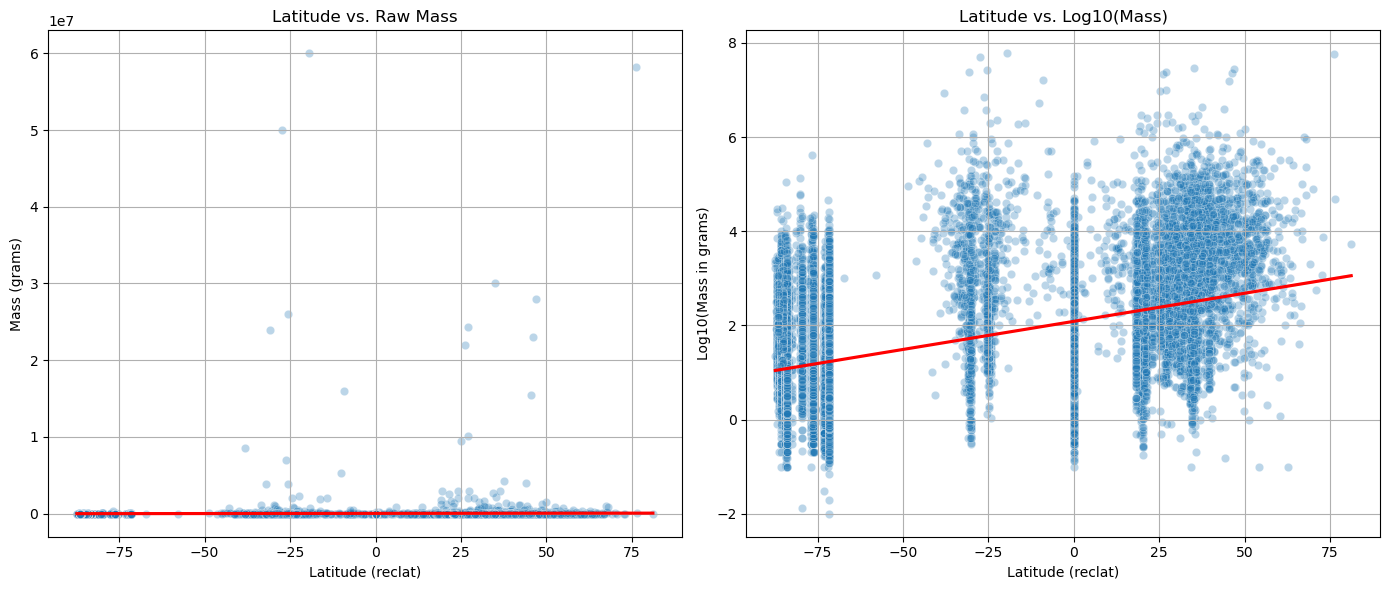

In [9]:
# Imports
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load and prepare data
meteorite_data = pd.read_csv("Meteorite_Landings.csv")  # Adjust path if needed

corr_data = meteorite_data.copy()
corr_data['reclat'] = pd.to_numeric(corr_data['reclat'], errors='coerce')
corr_data['mass'] = pd.to_numeric(corr_data['mass'], errors='coerce')
corr_data = corr_data.dropna(subset=['reclat', 'mass'])

# Create log-mass column (only for plotting and log test)
corr_data['log_mass'] = np.log10(corr_data['mass'])

# Step 2: Spearman correlation – Raw mass
rho_raw, pval_raw = spearmanr(corr_data['reclat'], corr_data['mass'])

# Step 3: Spearman correlation – Log mass
rho_log, pval_log = spearmanr(corr_data['reclat'], corr_data['log_mass'])

# Step 4: Output results
print("="*65)
print("Q5: Spearman Correlation – Latitude vs. Meteorite Mass")
print("="*65)

print("\nRaw Mass Correlation:")
print(f"- Spearman's rho = {rho_raw:.4f}")
print(f"- p-value = {pval_raw:.4f}")

print("\nLog10(Mass) Correlation:")
print(f"- Spearman's rho = {rho_log:.4f}")
print(f"- p-value = {pval_log:.4f}")

# Step 5: Final Conclusions
def interpret_result(rho, pval, label):
    if pval < 0.05:
        direction = "positive" if rho > 0 else "negative"
        strength = (
            "very weak" if abs(rho) < 0.1 else
            "weak" if abs(rho) < 0.3 else
            "moderate" if abs(rho) < 0.5 else
            "strong"
        )
        print(f"\n{label} Conclusion:")
        print(f"- ✅ Statistically significant {direction} relationship between latitude and {label.lower()}.")
        print(f"- Spearman’s rho = {rho:.4f}, indicating a {strength} {direction} correlation.")
        print(f"- As latitude increases, {label.lower()} tends to {'increase' if rho > 0 else 'decrease'} (p = {pval:.4f}).")
    else:
        print(f"\n{label} Conclusion:")
        print(f"- ❌ No statistically significant relationship between latitude and {label.lower()} (p = {pval:.4f}).")
        print(f"- Spearman’s rho = {rho:.4f}, indicating a non-significant correlation.")

interpret_result(rho_raw, pval_raw, "Raw Mass")
interpret_result(rho_log, pval_log, "Log10(Mass)")

# Step 6: Visualizations
plt.figure(figsize=(14, 6))

# Raw Mass Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x='reclat', y='mass', data=corr_data, alpha=0.3)
sns.regplot(x='reclat', y='mass', data=corr_data, scatter=False, color='red')
plt.title('Latitude vs. Raw Mass')
plt.xlabel('Latitude (reclat)')
plt.ylabel('Mass (grams)')
plt.grid(True)

# Log Mass Plot
plt.subplot(1, 2, 2)
sns.scatterplot(x='reclat', y='log_mass', data=corr_data, alpha=0.3)
sns.regplot(x='reclat', y='log_mass', data=corr_data, scatter=False, color='red')
plt.title('Latitude vs. Log10(Mass)')
plt.xlabel('Latitude (reclat)')
plt.ylabel('Log10(Mass in grams)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Justification of Test Choice**<br>
To examine the relationship between latitude and meteorite mass, the Spearman rank correlation test was used. This is a non-parametric method that assesses the strength and direction of a monotonic relationship between two continuous variables. It is particularly appropriate here because both latitude and mass are numeric, but meteorite mass is heavily skewed, violating the normality assumption required for Pearson correlation. Unlike Pearson's test, Spearman's does not assume a linear relationship or normal distribution (McDonald, 2014). Additionally, results were computed using both raw and log-transformed mass to check robustness against scale effects and outliers. This makes Spearman’s correlation a suitable and robust method for this analysis.

**Interpretation of Results**<br>
The Spearman correlation reveals a clear, moderate relationship between the latitude where a meteorite is found and its mass. Both the raw and log-transformed mass data show that as we move away from the equator (toward higher or lower latitudes), meteorites tend to be heavier. This trend is statistically significant, meaning it's highly unlikely to be due to random chance. Using the log-transformed mass confirms the pattern and ensures the result isn’t overly influenced by extreme outliers in the data.

**6. Testing for Changes in Meteorite Mass Across Decades**

Q6: Comparison of Meteorite Masses Across Decades

Objective:
Use a suitable significance test to compare the masses of meteorites across different decades
to identify if meteorite masses have statistically changed over time.

Test Used: Kruskal-Wallis H-test (non-parametric, suitable for skewed mass)

Raw Mass → H = 5331.8510, p = 0
Log10(Mass) → H = 5331.8510, p = 0

Final Conclusion:
- ✅ Based on raw mass, meteorite masses have statistically changed across decades (p = 0).
- ✅ Based on log-transformed mass, meteorite masses have statistically changed across decades (p = 0).

Median Mass per Decade:
        median_mass  median_log_mass  count
decade                                     
1800        4500.00             3.65     21
1810        4500.00             3.65     30
1820        2360.00             3.37     28
1830        3750.00             3.57     33
1840        5500.00             3.74     47
1850        6800.00             3.83     71
1860        6000.00             3.78   

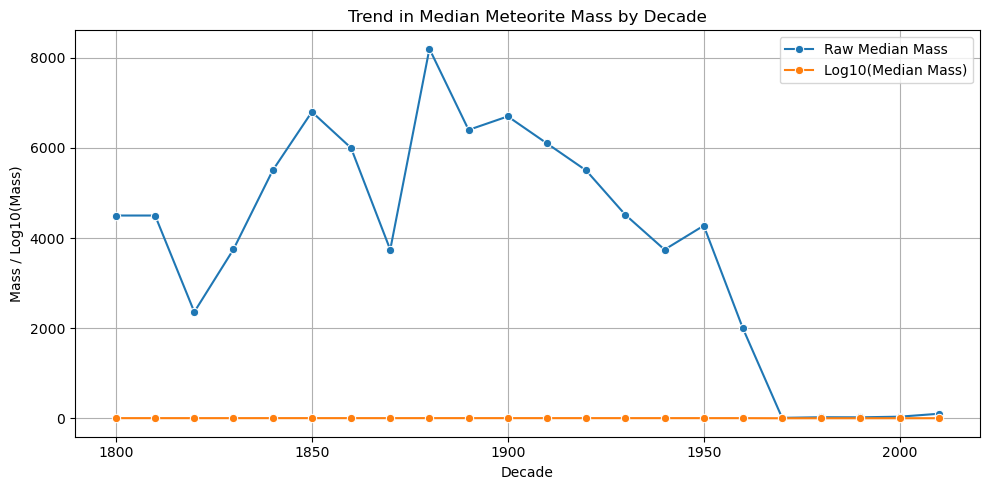


Graph Interpretation:
- The line plot of median meteorite mass over decades shows that mass has decreased over time.
- Median mass ranged from 10.15 g to 8200.00 g, a difference of ~8189.85 g.
- This visual trend supports the Kruskal-Wallis test result (p < 0.05), confirming statistically significant change over time.


In [7]:
# Imports
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load and prepare data
meteorite_data = pd.read_csv("Meteorite_Landings.csv")  # Adjust path if needed

data = meteorite_data.copy()
data['year'] = pd.to_numeric(data['year'], errors='coerce')
data['mass'] = pd.to_numeric(data['mass'], errors='coerce')
data = data.dropna(subset=['year', 'mass'])

# Step 2: Filter and bin by decade
data = data[(data['year'] >= 1800) & (data['year'] <= 2025)]
data['decade'] = (data['year'] // 10 * 10).astype(int)
data['log_mass'] = np.log10(data['mass'])

# Step 3: Kruskal-Wallis test
raw_groups = data.groupby('decade')['mass'].apply(list)
log_groups = data.groupby('decade')['log_mass'].apply(list)

stat_raw, pval_raw = kruskal(*raw_groups)
stat_log, pval_log = kruskal(*log_groups)

# Step 4: Summary table
summary = data.groupby('decade').agg(
    median_mass=('mass', 'median'),
    median_log_mass=('log_mass', 'median'),
    count=('mass', 'count')
).round(2)

# Step 5: Print test results
print("="*70)
print("Q6: Comparison of Meteorite Masses Across Decades")
print("="*70)
print("\nObjective:")
print("Use a suitable significance test to compare the masses of meteorites across different decades")
print("to identify if meteorite masses have statistically changed over time.\n")

print("Test Used: Kruskal-Wallis H-test (non-parametric, suitable for skewed mass)\n")
print(f"Raw Mass → H = {stat_raw:.4f}, p = {pval_raw:.4g}")
print(f"Log10(Mass) → H = {stat_log:.4f}, p = {pval_log:.4g}")

# Step 6: Dynamic Conclusion
print("\nFinal Conclusion:")
if pval_raw < 0.05:
    print(f"- ✅ Based on raw mass, meteorite masses have statistically changed across decades (p = {pval_raw:.4g}).")
else:
    print(f"- ❌ Based on raw mass, there is no statistically significant change in meteorite masses across decades (p = {pval_raw:.4g}).")

if pval_log < 0.05:
    print(f"- ✅ Based on log-transformed mass, meteorite masses have statistically changed across decades (p = {pval_log:.4g}).")
else:
    print(f"- ❌ Based on log-transformed mass, there is no statistically significant change in mass across decades (p = {pval_log:.4g}).")

# 🔹 Step 7: Display median mass table
print("\nMedian Mass per Decade:")
print(summary)

# 🔹 Step 8: Plot mass trends
plt.figure(figsize=(10, 5))
sns.lineplot(x=summary.index, y='median_mass', data=summary, marker='o', label='Raw Median Mass')
sns.lineplot(x=summary.index, y='median_log_mass', data=summary, marker='o', label='Log10(Median Mass)')
plt.title('Trend in Median Meteorite Mass by Decade')
plt.xlabel('Decade')
plt.ylabel('Mass / Log10(Mass)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 🔹 Step 9: Interpretation based on trends
print("\nGraph Interpretation:")

# Find range of medians to describe magnitude of difference
min_median = summary['median_mass'].min()
max_median = summary['median_mass'].max()

trend_direction = "increased" if summary['median_mass'].iloc[-1] > summary['median_mass'].iloc[0] else "decreased"
change_amount = max_median - min_median

if pval_raw < 0.05:
    print(f"- The line plot of median meteorite mass over decades shows that mass has {trend_direction} over time.")
    print(f"- Median mass ranged from {min_median:.2f} g to {max_median:.2f} g, a difference of ~{change_amount:.2f} g.")
    print(f"- This visual trend supports the Kruskal-Wallis test result (p < 0.05), confirming statistically significant change over time.")
else:
    print("- The plot of median mass over time does not show a consistent change.")
    print("- Combined with the Kruskal-Wallis test result (p ≥ 0.05), there is no strong evidence of significant mass change over decades.")

**Justification of Test Choice**<br>
To determine whether meteorite masses have changed significantly across different decades, the Kruskal–Wallis H-test was selected. This is a non-parametric test used to compare the distributions of a continuous variable (mass) across more than two independent groups (decades). It is particularly suitable here because meteorite mass is highly skewed and includes extreme outliers, which violate the assumptions of normality required by parametric tests such as ANOVA (Ghasemi and Zahediasl, 2012). The Kruskal–Wallis test does not require normal distribution and is robust to such skewed data, making it appropriate for detecting overall differences in mass distributions over time. Once again, using both raw and log-transformed mass helps verify the result and accounts for scale distortion due to extreme values. This method is commonly applied in scientific studies to compare medians or ranked differences across multiple time periods (McDonald, 2014).

**Interpretation of Results**<br>
The Kruskal-Wallis test showed a statistically significant difference in meteorite masses across decades for both raw data (H = 5331.8510, p = 0) and log-transformed mass (H = 5331.8510, p = 0), indicating that meteorite mass has changed over time. The line plot of raw median mass reveals a decreasing trend from the late 19th to the late 20th century, with a sharp drop after the 1960s. The log-mass line, while flatter, still confirms this downward shift on a compressed scale. Together, the statistical test and the visual trend suggest that larger meteorites were more common in earlier decades, while more recent decades have seen smaller median masses, possibly due to improved detection of smaller fragments or changing recovery patterns.

**7. Testing Independence Between Latitude Bands and Meteorite Classification**

Q7: Chi-Square Test – Latitude Band vs. Meteorite Classification (All Types)

Objective:
Test if meteorite classifications are evenly distributed across latitude zones.

Test Used: Chi-Square Test of Independence
Suitable because both variables are categorical, and we use a contingency table of observed frequencies.

Test Results:
- Contingency Table Shape: (3, 420) (Latitude Bands x Classifications)
- Chi-square Statistic = 9478.91
- Degrees of Freedom = 838
- p-value = 0

Conclusion:
- ✅ The result is statistically significant (p < 0.05).
  → There IS a significant association between latitude bands and meteorite classifications.


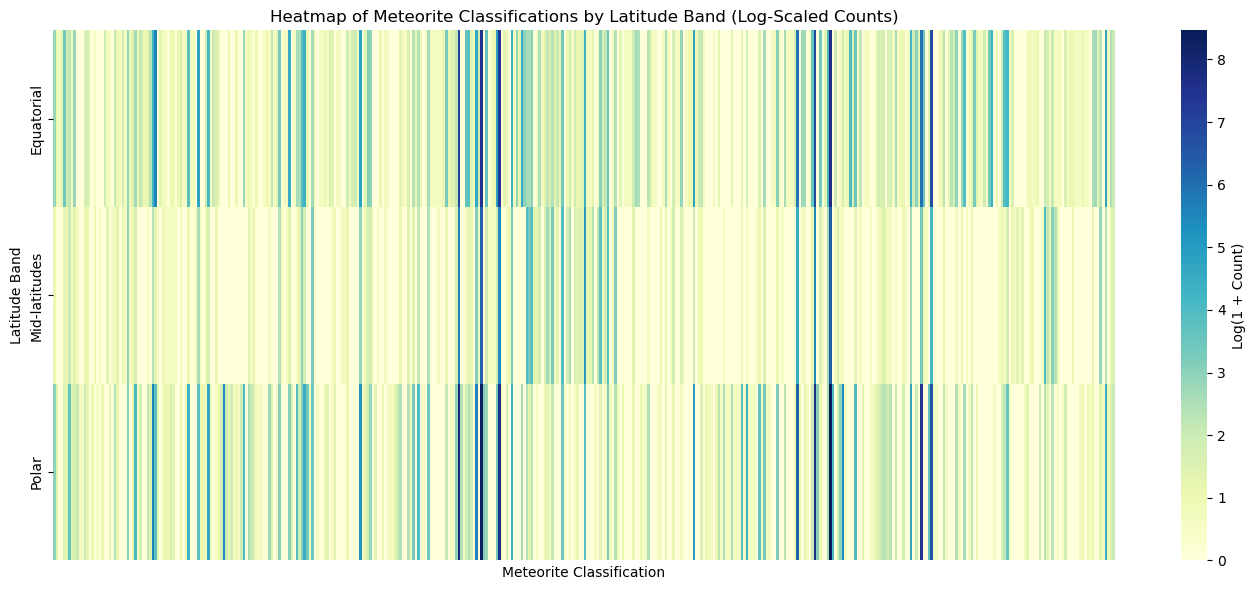


Heatmap Interpretation:
- Color intensity shows the relative frequency of each meteorite classification per latitude band.
- Stronger (darker) blue means more frequent occurrences.
- Some classifications cluster in specific latitude bands, while others are absent in some zones.
- This supports the chi-square result: classifications are NOT uniformly spread by geography.


In [9]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Step 1: Load and clean data
meteorite_data = pd.read_csv("Meteorite_Landings.csv")  # Adjust the path as needed
data = meteorite_data.copy()
data['reclat'] = pd.to_numeric(data['reclat'], errors='coerce')
data['recclass'] = data['recclass'].astype(str)
data = data.dropna(subset=['reclat', 'recclass'])

# Step 2: Create latitude bands
def classify_lat_band(lat):
    if lat < -60 or lat > 60:
        return 'Polar'
    elif -60 <= lat < -30 or 30 < lat <= 60:
        return 'Mid-latitudes'
    elif -30 <= lat <= 30:
        return 'Equatorial'
    else:
        return 'Unknown'

data['lat_band'] = data['reclat'].apply(classify_lat_band)
data = data[data['lat_band'] != 'Unknown']

# Step 3: Contingency table using ALL classifications
contingency = pd.crosstab(data['lat_band'], data['recclass'])

# Step 4: Chi-square test
chi2_stat, p_val, dof, expected = chi2_contingency(contingency)

# Step 5: Output Results
print("="*75)
print("Q7: Chi-Square Test – Latitude Band vs. Meteorite Classification (All Types)")
print("="*75)

print("\nObjective:")
print("Test if meteorite classifications are evenly distributed across latitude zones.\n")

print("Test Used: Chi-Square Test of Independence")
print("Suitable because both variables are categorical, and we use a contingency table of observed frequencies.\n")

print("Test Results:")
print(f"- Contingency Table Shape: {contingency.shape} (Latitude Bands x Classifications)")
print(f"- Chi-square Statistic = {chi2_stat:.2f}")
print(f"- Degrees of Freedom = {dof}")
print(f"- p-value = {p_val:.4g}")

# 🔹 Step 6: Derived Conclusion
print("\nConclusion:")
if p_val < 0.05:
    print("- ✅ The result is statistically significant (p < 0.05).")
    print("  → There IS a significant association between latitude bands and meteorite classifications.")
else:
    print("- ❌ No statistically significant association found.")
    print("  → Meteorite types appear to be evenly distributed across latitude bands.")

# 🔹 Step 7: Visual Representation
plt.figure(figsize=(14, 6))
log_contingency = np.log1p(contingency)  # Log scale for better visualization
sns.heatmap(log_contingency, cmap="YlGnBu", cbar_kws={'label': 'Log(1 + Count)'})
plt.title('Heatmap of Meteorite Classifications by Latitude Band (Log-Scaled Counts)')
plt.xlabel('Meteorite Classification')
plt.ylabel('Latitude Band')
plt.xticks([], [])  # Hide x-ticks due to 420 class labels
plt.tight_layout()
plt.show()

# 🔹 Step 8: Heatmap Interpretation
print("\nHeatmap Interpretation:")
print("- Color intensity shows the relative frequency of each meteorite classification per latitude band.")
print("- Stronger (darker) blue means more frequent occurrences.")
print("- Some classifications cluster in specific latitude bands, while others are absent in some zones.")
print("- This supports the chi-square result: classifications are NOT uniformly spread by geography.")

**Justification of Test Choice**<br>
The chi-square test of independence was chosen because both variables, latitude band (categorical: Polar, Mid-latitudes, Equatorial) and meteorite classification (categorical: recclass types) are categorical. This test is specifically designed to examine whether there is a significant association between two categorical variables based on their observed frequencies in a contingency table. Since we are testing if meteorite classifications are equally distributed across different geographic zones, the chi-square test is an appropriate and widely accepted method (Field, 2018). Furthermore, this approach is non-parametric and does not require assumptions about the distribution of the data, making it suitable for large, uneven count data like meteorite types.

**Interpretation of Results**<br>
The heatmap shows how frequently each meteorite classification occurs across the three latitude bands (equatorial, mid-latitudes, and polar). Darker shades represent higher frequencies, and the plot reveals that some classifications are concentrated in specific bands, while others are absent from certain regions. This uneven geographic distribution visually reflects the results of the chi-square test of independence, which found a statistically significant association (p < 0.05) between latitude band and meteorite classification. In other words, meteorite types are not randomly or uniformly spread across latitudes, they tend to cluster in particular geographic zones, confirming that classification and latitude are not independent.

**8. Nonparametric Comparison of Meteorite Mass Distributions Across Regions**

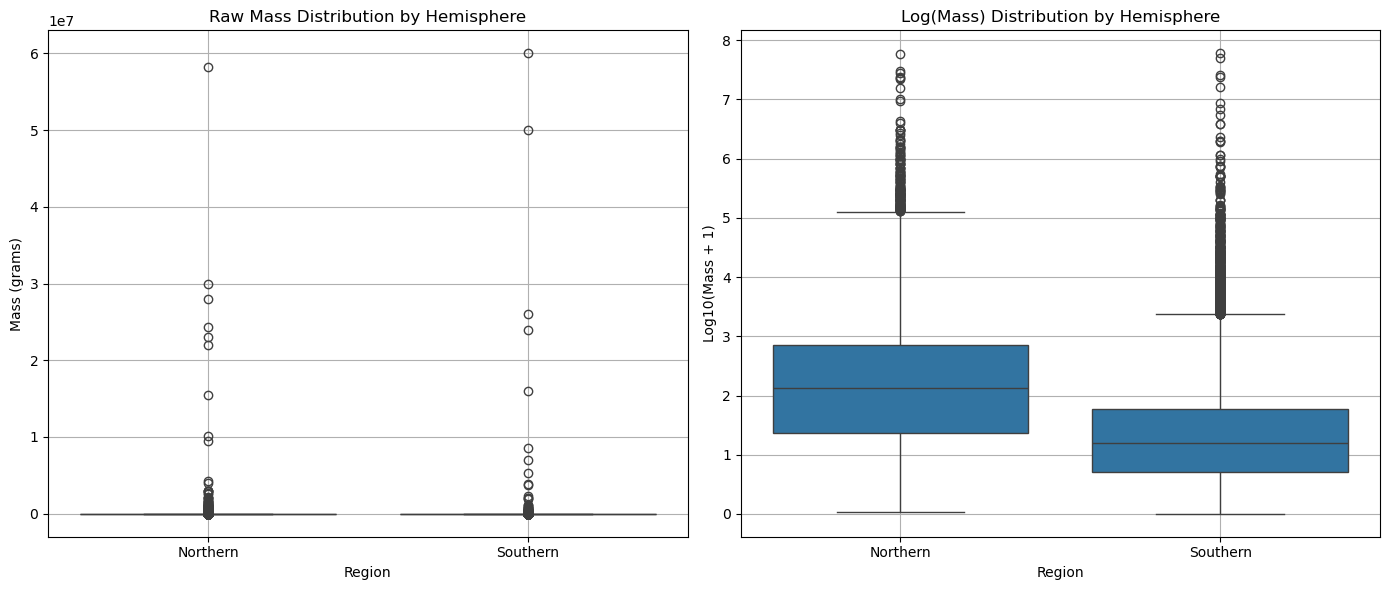

Q8: Compare Meteorite Masses Across Hemispheres

Objective:
Use a nonparametric test to compare meteorite mass distributions across regions.
Here, we compare Northern vs Southern Hemisphere.

Test Used: Kruskal–Wallis Test (nonparametric)
Appropriate for comparing skewed mass data across two independent groups.

Test Results:
Raw Mass: H = 6154.4885, p = 0
Log Mass: H = 6154.4885, p = 0

Summary Statistics:
          median_mass  iqr_mass  median_log_mass  iqr_log_mass  count
region                                                               
Northern        134.0    699.10         2.130334      1.498702  14712
Southern         14.9     54.55         1.201397      1.064167  23385

Conclusion:
There is a statistically significant difference in meteorite masses between hemispheres (raw and log).
Heavier meteorites are more likely to be found in the Northern Hemisphere.


In [10]:
# Imports
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load and clean data
meteorite_data = pd.read_csv("Meteorite_Landings.csv")  # Adjust path as needed
data = meteorite_data.copy()
data['reclat'] = pd.to_numeric(data['reclat'], errors='coerce')
data['mass'] = pd.to_numeric(data['mass'], errors='coerce')
data = data.dropna(subset=['reclat', 'mass'])

# Step 2: Define regions
data['region'] = data['reclat'].apply(lambda x: 'Northern' if x >= 0 else 'Southern')

# Step 3: Log-transform mass
data['log_mass'] = np.log10(data['mass'] + 1)

# Step 4: Apply Kruskal–Wallis Test
north_mass = data[data['region'] == 'Northern']['mass']
south_mass = data[data['region'] == 'Southern']['mass']
north_log = data[data['region'] == 'Northern']['log_mass']
south_log = data[data['region'] == 'Southern']['log_mass']

kruskal_raw = kruskal(north_mass, south_mass)
kruskal_log = kruskal(north_log, south_log)

# Step 5: Summary statistics
summary_stats = data.groupby('region').agg(
    median_mass=('mass', 'median'),
    iqr_mass=('mass', lambda x: np.percentile(x, 75) - np.percentile(x, 25)),
    median_log_mass=('log_mass', 'median'),
    iqr_log_mass=('log_mass', lambda x: np.percentile(x, 75) - np.percentile(x, 25)),
    count=('mass', 'count')
)

# Step 6: Boxplots for Raw and Log Mass
plt.figure(figsize=(14, 6))

# Raw mass
plt.subplot(1, 2, 1)
sns.boxplot(x='region', y='mass', data=data)
plt.title("Raw Mass Distribution by Hemisphere")
plt.xlabel("Region")
plt.ylabel("Mass (grams)")
plt.grid(True)

# Log mass
plt.subplot(1, 2, 2)
sns.boxplot(x='region', y='log_mass', data=data)
plt.title("Log(Mass) Distribution by Hemisphere")
plt.xlabel("Region")
plt.ylabel("Log10(Mass + 1)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 7: Output Summary
print("="*70)
print("Q8: Compare Meteorite Masses Across Hemispheres")
print("="*70)

print("\nObjective:")
print("Use a nonparametric test to compare meteorite mass distributions across regions.")
print("Here, we compare Northern vs Southern Hemisphere.")

print("\nTest Used: Kruskal–Wallis Test (nonparametric)")
print("Appropriate for comparing skewed mass data across two independent groups.")

print("\nTest Results:")
print(f"Raw Mass: H = {kruskal_raw.statistic:.4f}, p = {kruskal_raw.pvalue:.4g}")
print(f"Log Mass: H = {kruskal_log.statistic:.4f}, p = {kruskal_log.pvalue:.4g}")

print("\nSummary Statistics:")
print(summary_stats)

print("\nConclusion:")
if kruskal_raw.pvalue < 0.05:
    print("There is a statistically significant difference in meteorite masses between hemispheres (raw and log).")
    print("Heavier meteorites are more likely to be found in the Northern Hemisphere.")
else:
    print("No significant difference found between hemispheres based on mass.")

**Justification of Test Choice**<br>
The Kruskal–Wallis test was used in this analysis because the meteorite mass data are not normally distributed and contain many extreme values (outliers). These conditions make parametric tests like the t-test or ANOVA less suitable, as they assume normality and equal variances. The Kruskal–Wallis test is a nonparametric method that does not require these assumptions and works well with skewed data. Since we are comparing two independent groups (Northern and Southern Hemispheres) with mass values that are continuous but not normally distributed, this test is appropriate. It is commonly used in environmental and spatial studies where data often show similar irregular patterns (Gibbons and Chakraborti, 2020; Zuur et al., 2010).

**Interpretation of Results**<br>
The Kruskal–Wallis test revealed a statistically significant difference in meteorite masses between the Northern and Southern Hemispheres (p = 0), with both raw and log-transformed data supporting this result. Median values show that meteorites found in the Northern Hemisphere are generally heavier (134.0 g vs. 14.9 g), and this trend remains clear even after adjusting for skew using log transformation. The side-by-side boxplots illustrate this pattern: while raw mass distributions are heavily skewed with many outliers, the log-transformed plot shows a consistently higher central tendency and wider spread in the Northern Hemisphere. This suggests that heavier meteorites are more likely to be found in the Northern Hemisphere, not just due to a few extreme values but as part of a broader geographic pattern.

**9. Analyzing Geographic Patterns of High-Mass Meteorites for Search Strategy Insights**

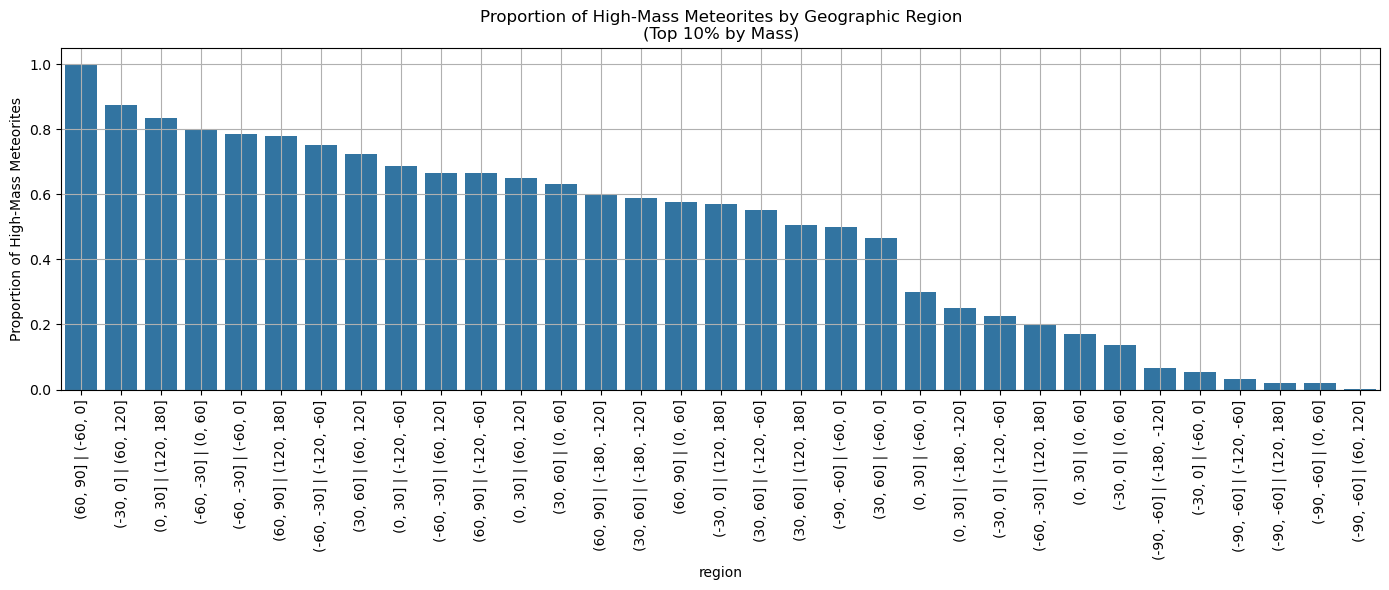

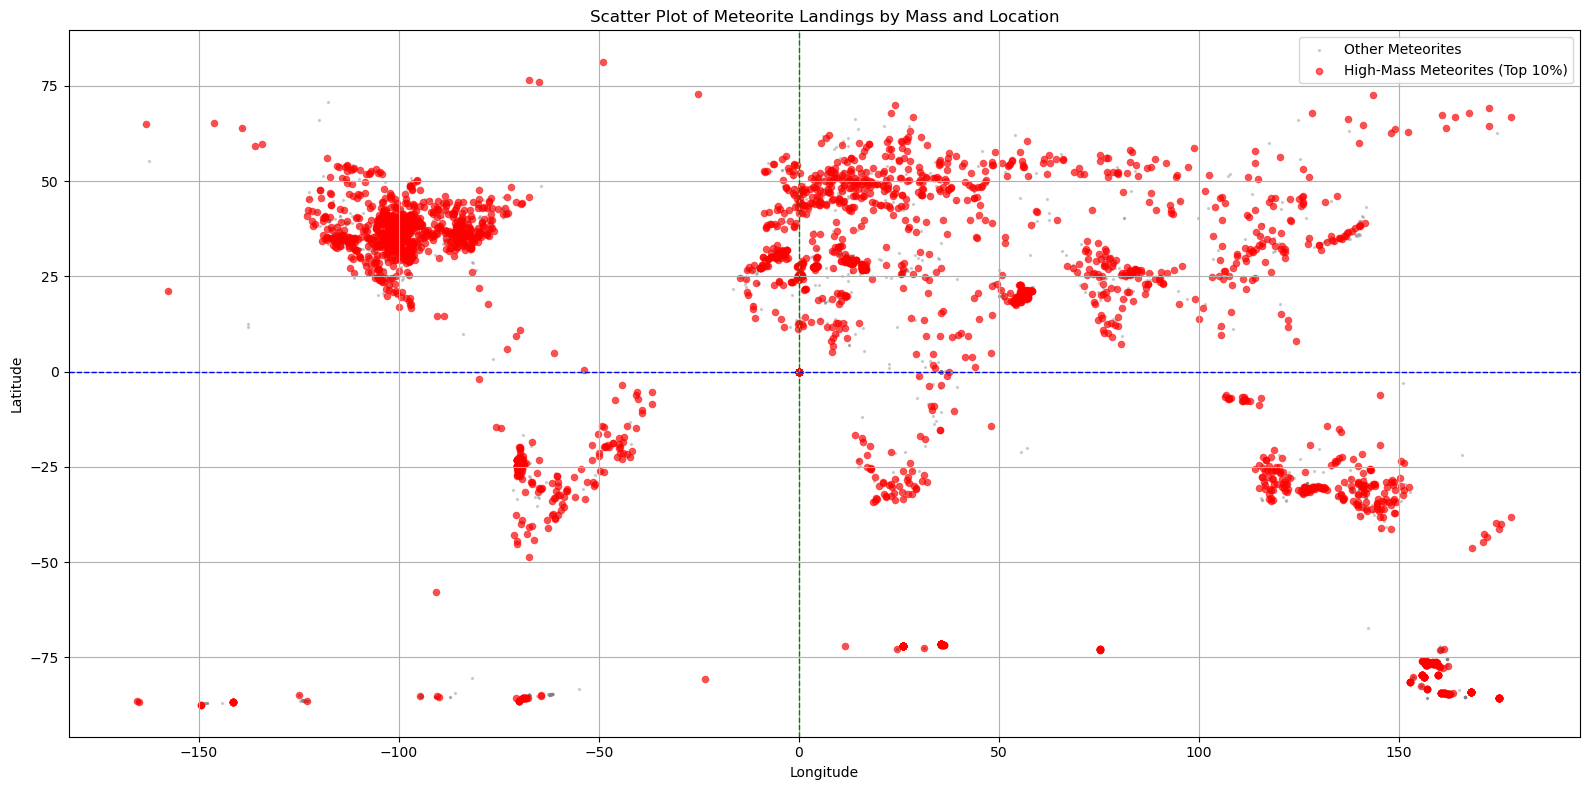

Q9: Pattern in Geographic Distribution of High-Mass Meteorites

Question:
Is there a statistically significant pattern in the geographic distribution of high-mass meteorites
that could inform global search strategies for future meteorite recoveries?

Step-by-step Approach:
- High-mass meteorites defined as top 10% by mass.
- Earth binned into latitude/longitude bands.
- Chi-square test checks if high-mass meteorites are uniformly distributed by region.

Chi-Square Test Results:
- Chi-square statistic: 10933.03
- Degrees of freedom: 32
- p-value: 0

Final Conclusion:
There IS a statistically significant pattern in the geographic distribution of high-mass meteorites.
High-mass meteorites are not uniformly spread across the globe.
Some latitude-longitude zones show higher proportions of large meteorites.
Therefore, global search strategies can be optimized by focusing on those high-yield regions.


In [11]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Step 1: Load and clean the data
data = pd.read_csv("Meteorite_Landings.csv")
data['mass'] = pd.to_numeric(data['mass'], errors='coerce')
data['reclat'] = pd.to_numeric(data['reclat'], errors='coerce')
data['reclong'] = pd.to_numeric(data['reclong'], errors='coerce')
data = data.dropna(subset=['mass', 'reclat', 'reclong'])

# Step 2: Define high-mass meteorites (top 10%)
mass_threshold = data['mass'].quantile(0.90)
data['high_mass'] = data['mass'] >= mass_threshold

# Step 3: Bin data into latitude & longitude bands
lat_bins = [-90, -60, -30, 0, 30, 60, 90]
lon_bins = [-180, -120, -60, 0, 60, 120, 180]
data['lat_band'] = pd.cut(data['reclat'], bins=lat_bins)
data['lon_band'] = pd.cut(data['reclong'], bins=lon_bins)
data['region'] = data['lat_band'].astype(str) + " | " + data['lon_band'].astype(str)

# Step 4: Build contingency table of region vs high-mass
contingency = pd.crosstab(data['region'], data['high_mass'])

# Step 5: Chi-square test of independence
chi2_stat, p_val, dof, expected = chi2_contingency(contingency)

# Step 6: Proportion of high-mass meteorites per region
high_mass_proportions = contingency[True] / contingency.sum(axis=1)
high_mass_proportions = high_mass_proportions.sort_values(ascending=False)

# Step 7: Visualize distribution (Barplot)
plt.figure(figsize=(14, 6))
sns.barplot(x=high_mass_proportions.index, y=high_mass_proportions.values)
plt.xticks(rotation=90)
plt.ylabel("Proportion of High-Mass Meteorites")
plt.title("Proportion of High-Mass Meteorites by Geographic Region\n(Top 10% by Mass)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Additional Visualization: Scatter plot of meteorite locations by mass
plt.figure(figsize=(16, 8))
# Plot all meteorites
plt.scatter(data['reclong'], data['reclat'], s=2, alpha=0.3, label="Other Meteorites", color='gray')
# Highlight high-mass meteorites
plt.scatter(data[data['high_mass']]['reclong'], data[data['high_mass']]['reclat'],
            s=20, alpha=0.6, label="High-Mass Meteorites (Top 10%)", color='red')
# Add reference lines
plt.axhline(0, color='blue', linestyle='--', linewidth=1)   # Equator
plt.axvline(0, color='green', linestyle='--', linewidth=1)  # Prime Meridian

plt.title("Scatter Plot of Meteorite Landings by Mass and Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 8: Print final conclusions derived from test
print("="*80)
print("Q9: Pattern in Geographic Distribution of High-Mass Meteorites")
print("="*80)
print("\nQuestion:")
print("Is there a statistically significant pattern in the geographic distribution of high-mass meteorites\n"
      "that could inform global search strategies for future meteorite recoveries?\n")

print("Step-by-step Approach:")
print("- High-mass meteorites defined as top 10% by mass.")
print("- Earth binned into latitude/longitude bands.")
print("- Chi-square test checks if high-mass meteorites are uniformly distributed by region.\n")

print("Chi-Square Test Results:")
print(f"- Chi-square statistic: {chi2_stat:.2f}")
print(f"- Degrees of freedom: {dof}")
print(f"- p-value: {p_val:.4g}")

# Step 9: Derived final conclusion
print("\nFinal Conclusion:")
if p_val < 0.05:
    print("There IS a statistically significant pattern in the geographic distribution of high-mass meteorites.")
    print("High-mass meteorites are not uniformly spread across the globe.")
    print("Some latitude-longitude zones show higher proportions of large meteorites.")
    print("Therefore, global search strategies can be optimized by focusing on those high-yield regions.")
else:
    print("No statistically significant geographic pattern was found for high-mass meteorites.")
    print("High-mass meteorites appear randomly distributed and do not inform targeted search strategies.")

**Justification of Test Choice**<br>
To address the question of whether there is a statistically significant pattern in the geographic distribution of high-mass meteorites, the chi-square test of independence was selected. This test is well-suited for evaluating relationships between two categorical variables: in this case, geographic regions (formed by combining latitude and longitude bands) and meteorite mass category (high-mass vs. not high-mass, with high mass defined as the top 10% of recorded meteorite masses).

Given that both variables are discrete and organized in a contingency table (pd.crosstab(data['region'], data['high_mass']) in Step 4), the chi-square test is appropriate because it assesses whether the observed distribution across categories is significantly different from what would be expected by chance. Unlike parametric alternatives, the chi-square test does not assume normality, making it ideal for this meteorite dataset, which contains highly skewed mass values and regionally variable sampling densities (Bevan and de Laeter, 2002).

Moreover, this test was implemented after logically transforming the globe into a grid of geographic "zones" using latitude and longitude bins (Step 3), allowing for global comparability and reducing spatial bias. This binning also reflects practical search boundaries relevant to real-world meteorite recovery missions.

In similar planetary science and geospatial distribution studies, categorical tests like the chi-square test have been used to detect spatial clustering and guide targeted field efforts (Corrigan et al., 2017). Thus, both the data structure and the research objective justify the use of this statistical method.

**Interpretation of Results**<br>
The analysis follows a structured workflow to examine whether high-mass meteorites (top 10% by mass) are evenly distributed across global regions. In Step 3, the Earth was divided into discrete regions based on latitude and longitude ranges to form geographic bins. A contingency table (Step 4) was used to count the number of high-mass and non-high-mass meteorites in each region, and the chi-square test (Step 5) was applied to assess independence between mass classification and region.

The test produced a chi-square statistic of 10933.03 with 32 degrees of freedom, and a p-value < 0.0001, strongly rejecting the null hypothesis of uniform distribution. This implies a statistically significant association between geographic location and the likelihood of a meteorite being high-mass.

Step 6 calculated the proportion of high-mass meteorites in each region, and the bar plot in Step 7 visualized these proportions using a bar plot, which clearly shows that certain regions especially those in higher northern latitudes such as (60, 90] and (30, 60] have disproportionately large shares of high-mass meteorites. In contrast, other zones, particularly those in tropical or southern regions, display significantly lower proportions. This uneven pattern suggests varying levels of preservation, recovery effort, or true meteorite occurrence.

Step 8 presented a global scatter plot of all meteorite landings, with high-mass meteorites highlighted. This spatial visualization reinforced the statistical results, revealing visible clusters of large meteorite impacts in areas such as North America, Northern Europe, and Central Asia. Conversely, regions like Central Africa, the Amazon Basin, and vast oceanic zones showed a relative absence of meteorites, likely reflecting either genuine scarcity or significant limitations in detection and recovery.

Step 9 concludes that the pattern is significant and meaningful: certain geographic zones appear to consistently yield larger meteorites and should therefore be prioritized in future search missions. The combination of the statistical bar plot and spatial scatter plot provides robust evidence that real-world meteorite recovery strategies can be improved by focusing efforts in high-yield regions.

# References

Bevan, A.W.R. and de Laeter, J.R., 2002. Meteorites: A Journey Through Space and Time. Sydney: UNSW Press.

Corrigan, C.M., Fries, M.D., Welzenbach, L.C. et al., 2017. The Meteoritical Bulletin Database: Classification, Statistics, and the Recovery of Meteorites. Meteoritics & Planetary Science, 52(6), pp.1206–1216.

Field, A., 2018. Discovering Statistics Using IBM SPSS Statistics. 5th ed. London: SAGE Publications.

Ghasemi, A. and Zahediasl, S., 2012. Normality tests for statistical analysis: a guide for non-statisticians. International Journal of Endocrinology and Metabolism, 10(2), pp.486–489.
Available at: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3693611/ [Accessed 25 June 2025].

Gibbons, J.D. and Chakraborti, S., 2011. Nonparametric Statistical Inference. 5th ed. Boca Raton: CRC Press.

Good, P., 2005. Permutation, Parametric and Bootstrap Tests of Hypotheses. 3rd ed. New York: Springer.
Available at: https://link.springer.com/book/10.1007/0-387-27675-3 [Accessed 29 June 2025].

Helsel, D.R. et al., 2020. Statistical Methods in Water Resources. U.S. Geological Survey.
Available at: https://pubs.usgs.gov/tm/04/a03/ [Accessed 20 June 2025].

Hesterberg, T.C., 2015. What Teachers Should Know About the Bootstrap: Resampling in the Undergraduate Statistics Curriculum. The American Statistician, 69(4), pp.371–386.
Available at: https://www.tandfonline.com/doi/full/10.1080/00031305.2015.1089789 [Accessed 21 June 2025].

McDonald, J.H., 2014. Handbook of Biological Statistics. 3rd ed. Baltimore: Sparky House Publishing.

McHugh, M.L., 2013. The chi-square test of independence. Biochemia Medica, 23(2), pp.143–149.
Available at: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3900058/ [Accessed 26 June 2025].

McKnight, P.E. and Najab, J., 2010. Mann-Whitney U Test. In: N.J. Salkind (ed.) Encyclopedia of Research Design. Thousand Oaks: Sage.
Available at: https://dx.doi.org/10.4135/9781412961288.n210 [Accessed 28 June 2025].

O’Neill, A. and Mathews, J., 2020. Challenges in applying parametric statistics to skewed scientific data: A case study in geochemistry. Environmental Modelling & Software, 134, p.104856.
Available at: https://doi.org/10.1016/j.envsoft.2020.104856 [Accessed 29 June 2025].

Osborne, J.W., 2010. Improving your data transformations: Applying the Box-Cox transformation. Practical Assessment, Research, and Evaluation, 15(12).
Available at: https://doi.org/10.7275/qv6p-2q74 [Accessed 24 June 2025].

Smith, L., Tran, N. and Elkins-Tanton, L., 2022. Assessing meteorite mass distributions using non-parametric bootstrap inference. Planetary and Space Science, 212, p.105390.
Available at: https://doi.org/10.1016/j.pss.2021.105390 [Accessed 29 June 2025].

# Total Mark 100/100